In [174]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split


sns.set_theme(style="whitegrid")

In [175]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]  
data_path = "Data_clean/Stocks clean"
sp500_path = "Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [176]:
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col = "Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

sp500_df = pd.read_csv(sp500_path, index_col = "Date", parse_dates = True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]



In [177]:
df = df.sort_index()
start_date = '2015-01-01'
df = df.loc[start_date:]
df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2015-01-01,103.995,43.411,530.105,309.435,19.512,58.0075,17.208,186.895,82.712,113.83,96.8385,38.5635,194.345
2015-01-02,103.500,43.555,529.550,308.520,19.552,58.1520,17.213,187.180,82.880,114.08,96.8140,38.5260,194.290
2015-01-05,100.580,43.154,519.460,302.190,19.221,56.3470,16.715,181.330,80.613,115.80,96.1290,38.5260,190.770
2015-01-06,100.590,42.520,506.640,295.290,18.636,54.8860,16.212,177.660,80.186,117.12,95.6670,38.8210,188.990
2015-01-07,102.010,43.062,505.150,298.420,18.586,54.9690,16.292,180.320,80.998,116.43,97.7710,39.3040,191.310


In [178]:
returns_df = df[core_stocks].pct_change()
returns_df['spy'] = df['spy'].pct_change().shift(-1)
returns_df = returns_df.loc["2015-01-02":]
returns_df = returns_df.dropna()
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2015-01-02,-0.004760,0.003317,-0.001047,-0.002957,0.002050,0.002491,0.000291,0.001525,0.002031,0.002196,-0.000253,-0.000972,-0.018117
2015-01-05,-0.028213,-0.009207,-0.019054,-0.020517,-0.016929,-0.031039,-0.028932,-0.031253,-0.027353,0.015077,-0.007075,0.000000,-0.009331
2015-01-06,0.000099,-0.014692,-0.024679,-0.022833,-0.030435,-0.025929,-0.030093,-0.020239,-0.005297,0.011399,-0.004806,0.007657,0.012276
2015-01-07,0.014117,0.012747,-0.002941,0.010600,-0.002683,0.001512,0.004935,0.014972,0.010126,-0.005891,0.021993,0.012442,0.017929
2015-01-08,0.038428,0.029423,0.003484,0.006836,0.037878,0.022340,0.020501,0.015916,0.016655,-0.004209,0.007916,0.012085,-0.008113


In [179]:
X = returns_df[core_stocks]
y = returns_df["spy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)
model = xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.05, max_depth = 3, random_state = 42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 0.0030227235023309166


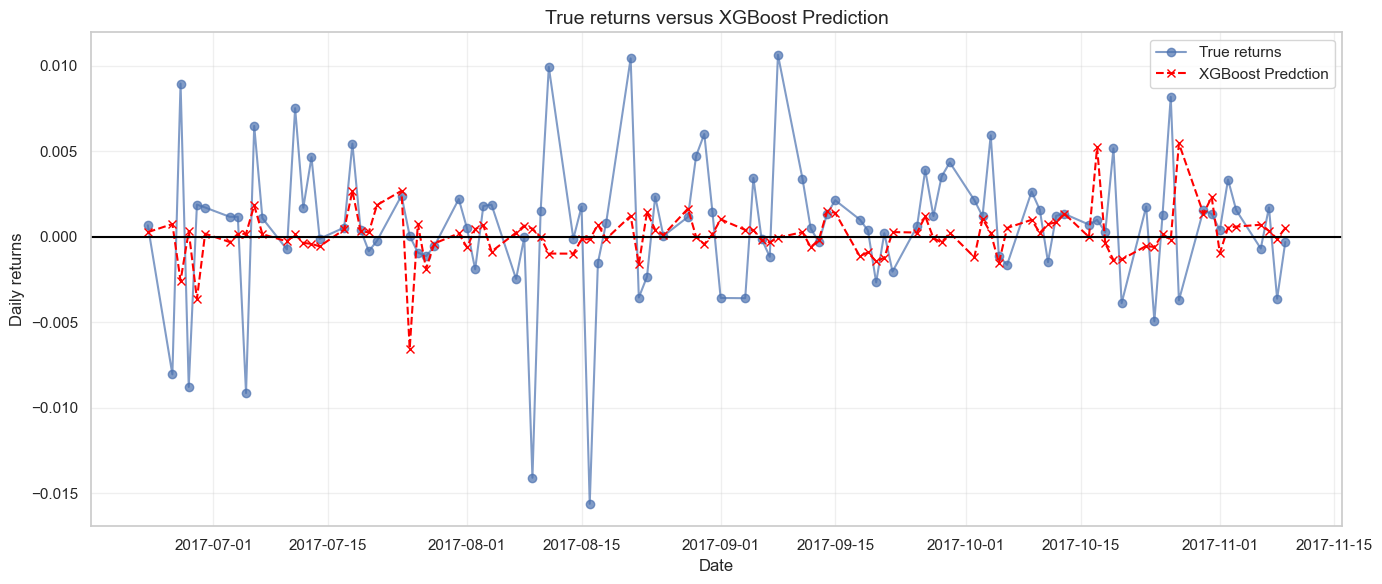

In [180]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='XGBoost Predction', marker='x', linestyle='--', color='red')
plt.title('True returns versus XGBoost Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

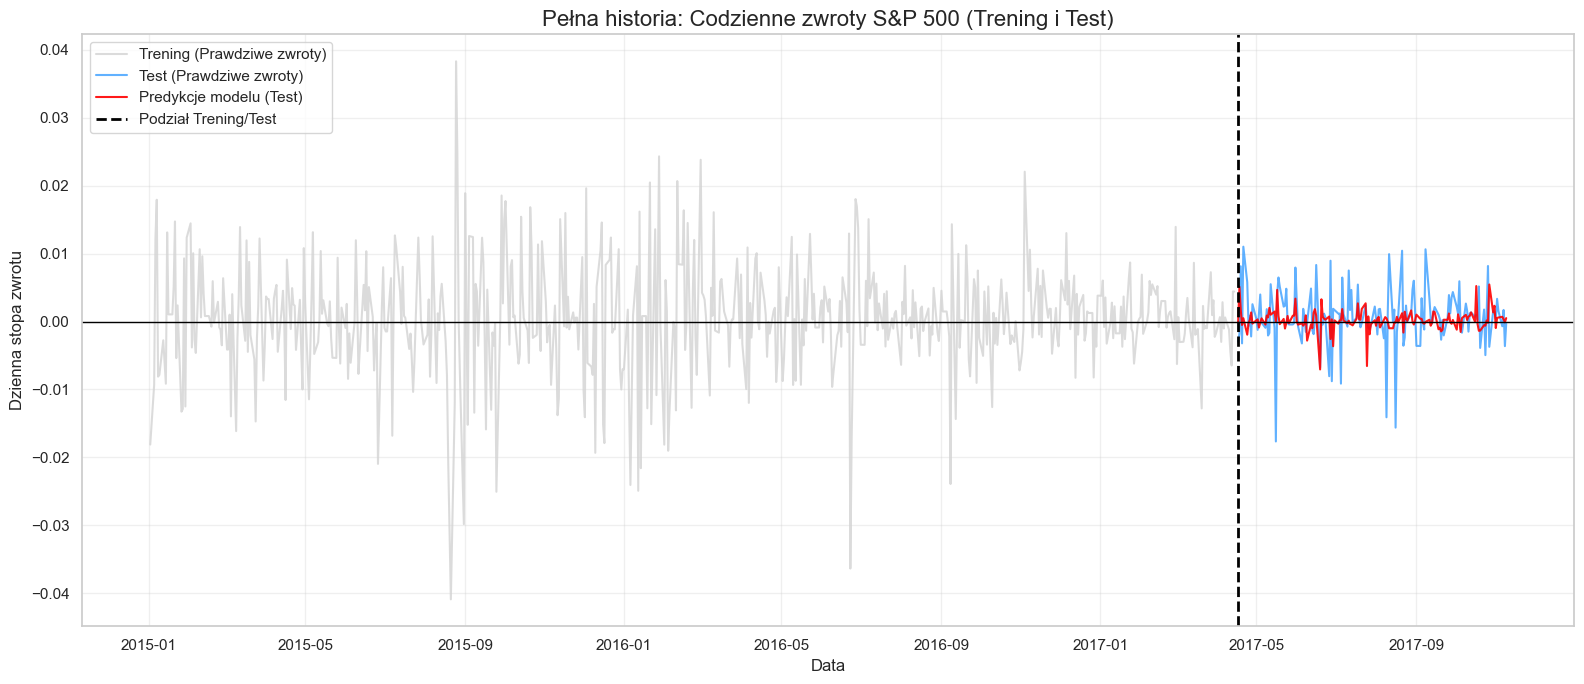

In [ ]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()